<a href="https://colab.research.google.com/github/OCR-tech/AdaptDL/blob/main/Exercise%20Solutions/%F0%9F%9B%A0%20%2001_Neural_network_regression_in_Tensorflow1ok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠 01_Neural_network_regression_in_Tensorflow

- Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it.
- Try building a neural network with 4 Dense layers and fitting it to your own regression dataset, how does it perform?
- Try and improve the results we got on the insurance dataset, some things you might want to try include:
    - Building a larger model (how does one with 4 dense layers go?).
    - Increasing the number of units in each layer.
    - Lookup the documentation of Adam and find out what the first parameter is,what happens if you increase it by 10x?
    - What happens if you train for longer (say 300 epochs instead of 200)?
- Import the Boston pricing dataset from TensorFlow `tf.keras.datasets` and model it.

In [13]:
import tensorflow as tf
import tensorflow_datasets as tfds

## 1. Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it.




In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X , y  = make_regression(n_samples = 200 ,
                               n_features = 10 ,
                               n_targets = 1)

X.shape , y.shape

((200, 10), (200,))

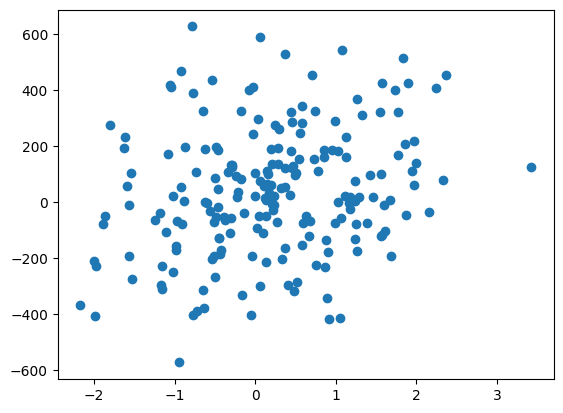

In [15]:
# Let's visualize the dataset

plt.scatter(X[:, 0] , y)

In [16]:
# Modelling our dummy data

# Set the random seed
tf.random.set_seed(42)

# Create a model using the Sequential API
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss = tf.keras.losses.mae ,
              optimizer = tf.keras.optimizers.Adam() ,
              metrics = ['mae'])

# Fitting the model
model.fit(X , y , epochs = 10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 173.1923 - mae: 173.1923  
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 173.1786 - mae: 173.1786 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 173.1657 - mae: 173.1657 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 173.1529 - mae: 173.1529 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 173.1402 - mae: 173.1402 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 173.1274 - mae: 173.1274 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 173.1147 - mae: 173.1147 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 173.1020 - mae: 173.1020 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 173.0893 - mae: 173.0893 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 173.0765 - mae: 173.0765 


## 2. Try building a neural network with 4 Dense layers and fitting it to your own regression dataset, how does it perform?

In [17]:
# Building the model again with 4 Dense layers
tf.random.set_seed(42)

# Build the model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(10) ,
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss = tf.keras.losses.mae ,
              optimizer = tf.keras.optimizers.Adam() ,
              metrics = ['mae'])

# Fit the model
model.fit(X , y , epochs= 10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 172.5561 - mae: 172.5561
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 172.3642 - mae: 172.3642 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 172.1698 - mae: 172.1698 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 171.9606 - mae: 171.9606 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 171.7313 - mae: 171.7313 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 171.4766 - mae: 171.4766 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 171.1907 - mae: 171.1907 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 170.8673 - mae: 170.8673 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 170.4997 - mae: 170.4997 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 170.0932 - mae: 170.0932 


Hmm..Seems the model isn't improving maybe running for more epochs would do the magic. But let's split this into train and test set to help our model to generalize well.

In [18]:
# Splitting the data into train and test splits
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 )

# Checking the shapes of our splitted data
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((160, 10), (160,), (40, 10), (40,))

In [28]:
X_train

array([[ 0.67497996,  0.31741306, -1.75015328, ..., -1.84925812,
        -0.19358159, -0.57269716],
       [-1.08479732, -0.57833522, -0.67498837, ...,  1.3165264 ,
        -0.72432662,  0.36011326],
       [ 1.45831046, -0.06360587, -1.59356793, ..., -1.17680746,
         1.04969692, -0.01375218],
       ...,
       [ 2.36330695, -0.29378399,  1.14168954, ..., -1.24886228,
         0.68697245,  0.34985228],
       [-0.96585654, -0.31734359,  0.20895668, ...,  0.5210417 ,
         0.37745613, -0.49223164],
       [-1.10702276, -0.25100136, -1.51449838, ..., -0.82901319,
        -0.22307377,  0.16880787]])

In [29]:
y_train

array([ -66.28104945,  172.08097497,   18.59439937, -152.45114827,
        -40.00312886,   62.46889851, -283.75324293, -222.91301652,
       -343.28743778, -309.08483461,  -79.40676994, -273.99426396,
        401.16277471, -267.15516416,  407.73548179, -130.28144045,
         54.83203395,  122.378659  ,   94.94902171,  194.49455739,
        324.65039546, -127.39537915, -174.43406081,  186.46850454,
       -169.31702276, -405.37556515,  275.18843667,  -64.46875664,
         22.684342  ,   46.27091938,  516.91114957,  -73.57283635,
       -377.02561883,  185.33086281, -212.3680407 ,   56.6411519 ,
        367.28232051, -202.27177965,   20.97046464,  411.75742989,
       -110.4395244 , -192.92680381,  131.02586808,   95.64876512,
        189.04156805,  -50.91180975,  543.67472571, -294.53703992,
        402.91977519,  628.44670016, -413.37866591, -317.85572783,
        102.82521752, -108.67581294,   -6.21566291, -121.32614121,
        342.89428992,   37.75753362,  -73.82740962, -155.44526

In [30]:
X_train.shape, y_train.shape

((160, 10), (160,))

In [31]:
# Let's build the model from scratch
tf.random.set_seed(42)

# Model 1 with one layer and fewer units
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss = tf.keras.losses.mae ,
                optimizer = tf.keras.optimizers.Adam() ,
                metrics = ['mae'])

# Fit the model only our training data
model.fit(X_train , y_train , epochs = 100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2112 - mae: 0.2112  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2142 - mae: 0.2142  
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2417 - mae: 0.2417 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2304 - mae: 0.2304 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1703 - mae: 0.1703  
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2875 - mae: 0.2875 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2252 - mae: 0.2252 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2180 - mae: 0.2180 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2025 - mae: 0.2025 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1940 - mae: 0.1940 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2486 - mae: 0.2486 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2120 - mae: 0.2120 
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/s

In [20]:
# Evaluating our model on the test data (unseen data)
model_1.evaluate(X_test , y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 165.0757 - mae: 165.0757 


[165.76040649414062, 165.76040649414062]

In [21]:
# Getting the predictions of our model
y_preds_1 = model_1.predict(X_test)
y_preds_1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[ 1.6277695 ],
       [ 1.584855  ],
       [-2.0198388 ],
       [ 1.2984506 ],
       [-2.0376818 ],
       [ 0.5542696 ],
       [ 1.2465346 ],
       [ 0.6125699 ],
       [ 2.3750327 ],
       [ 0.2824803 ],
       [ 0.29670393],
       [-2.529092  ],
       [ 0.9307196 ],
       [-0.6291981 ],
       [ 0.05892372],
       [-0.5183766 ],
       [-1.2941376 ],
       [ 1.6047761 ],
       [-1.821793  ],
       [-0.16008222],
       [ 1.1947687 ],
       [-0.08406674],
       [ 0.72126305],
       [ 2.5401368 ],
       [ 0.21785682],
       [-1.039397  ],
       [-0.6688073 ],
       [-1.3763393 ],
       [ 0.3794815 ],
       [ 0.4398948 ],
       [-0.9372531 ],
       [ 1.6588202 ],
       [ 1.8978056 ],
       [ 1.0971472 ],
       [-0.22475934],
       [-0.34351563],
       [ 1.606651  ],
       [ 1.0882965 ],
       [-0.70443565],
       [-0.05864915]], dtype=float32)

In [22]:
def plot_predictions(train_data,
                     train_labels,
                     test_data,
                     test_labels,
                     predictions):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

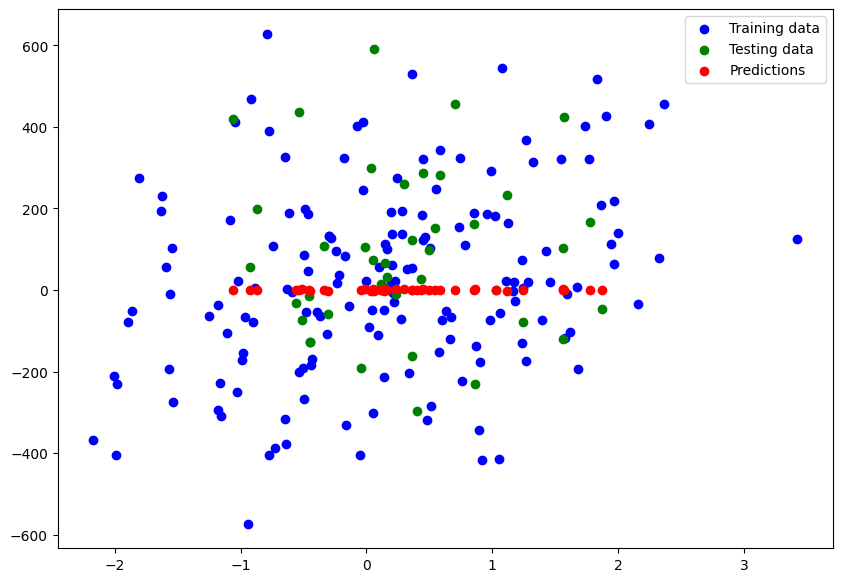

In [23]:
# Plotting our predictions with our target
plot_predictions(X_train[:,0] , y_train ,
                 X_test[:,0] , y_test , y_preds_1)

Great! Our model is trying to predict the points but it's not doing a great job with it.

Let's try couple of experiments and see how it goes.


In [25]:
X_train

array([[ 0.67497996,  0.31741306, -1.75015328, ..., -1.84925812,
        -0.19358159, -0.57269716],
       [-1.08479732, -0.57833522, -0.67498837, ...,  1.3165264 ,
        -0.72432662,  0.36011326],
       [ 1.45831046, -0.06360587, -1.59356793, ..., -1.17680746,
         1.04969692, -0.01375218],
       ...,
       [ 2.36330695, -0.29378399,  1.14168954, ..., -1.24886228,
         0.68697245,  0.34985228],
       [-0.96585654, -0.31734359,  0.20895668, ...,  0.5210417 ,
         0.37745613, -0.49223164],
       [-1.10702276, -0.25100136, -1.51449838, ..., -0.82901319,
        -0.22307377,  0.16880787]])

In [26]:
y_train

array([ -66.28104945,  172.08097497,   18.59439937, -152.45114827,
        -40.00312886,   62.46889851, -283.75324293, -222.91301652,
       -343.28743778, -309.08483461,  -79.40676994, -273.99426396,
        401.16277471, -267.15516416,  407.73548179, -130.28144045,
         54.83203395,  122.378659  ,   94.94902171,  194.49455739,
        324.65039546, -127.39537915, -174.43406081,  186.46850454,
       -169.31702276, -405.37556515,  275.18843667,  -64.46875664,
         22.684342  ,   46.27091938,  516.91114957,  -73.57283635,
       -377.02561883,  185.33086281, -212.3680407 ,   56.6411519 ,
        367.28232051, -202.27177965,   20.97046464,  411.75742989,
       -110.4395244 , -192.92680381,  131.02586808,   95.64876512,
        189.04156805,  -50.91180975,  543.67472571, -294.53703992,
        402.91977519,  628.44670016, -413.37866591, -317.85572783,
        102.82521752, -108.67581294,   -6.21566291, -121.32614121,
        342.89428992,   37.75753362,  -73.82740962, -155.44526

In [27]:
X_train.shape, y_train.shape

((160, 10), (160,))

In [34]:
# Building a model with 2 layers and fewer units
tf.random.set_seed(42)

# Build the model
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(10) ,
  # tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1),
])

# Compile the model
model_2.compile(loss = tf.keras.losses.mae ,
                optimizer = tf.keras.optimizers.Adam() ,
                metrics = ['mae'])

# Fit the model
model_2.fit(X_train , y_train , epochs = 100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 187.1947 - mae: 187.1947  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187.1457 - mae: 187.1457 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187.0974 - mae: 187.0974 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187.0487 - mae: 187.0487 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 186.9992 - mae: 186.9992 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 186.9491 - mae: 186.9491 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 186.8980 - mae: 186.8980 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 186.8459 - mae: 186.8459 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 186.7927 - mae: 186.7927 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 186.7382 - mae: 186.7382 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 186.6824 - mae: 186.6824 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 186.6251 - mae: 186.6251 


In [33]:
# Building our model with 3 layers and with more hidden units

tf.random.set_seed(42)

# Creating the model
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(50),
  tf.keras.layers.Dense(1) # Should be always one
])

# Compile the model
model_3.compile(loss = tf.keras.losses.mae ,
                optimizer = tf.keras.optimizers.Adam() ,
                metrics = ['mae'])

# Fit the model
model_3.fit(X_train , y_train , epochs = 100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 187.6360 - mae: 187.6360  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187.0714 - mae: 187.0714 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 186.4774 - mae: 186.4774 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 185.8139 - mae: 185.8139 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 185.0487 - mae: 185.0487 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 184.1465 - mae: 184.1465  
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 183.0713 - mae: 183.0713 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 181.7845 - mae: 181.7845 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 180.2408 - mae: 180.2408 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178.3907 - mae: 178.3907 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 176.2020 - mae: 176.2020 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 173.6169 - mae: 173.6169 

Woooo! Look at that, but we shouldn't be excited lets evaluate on the test data.

In [35]:
model_3.evaluate(X_test , y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3342 - mae: 0.3342


[0.32765769958496094, 0.32765769958496094]

Awesome! This is what we want error should be loss. Let's plot our predictions with targets!

In [36]:
# Making predictions
y_preds_3 = model_3.predict(X_test)
y_preds_3.shape

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


(40, 1)

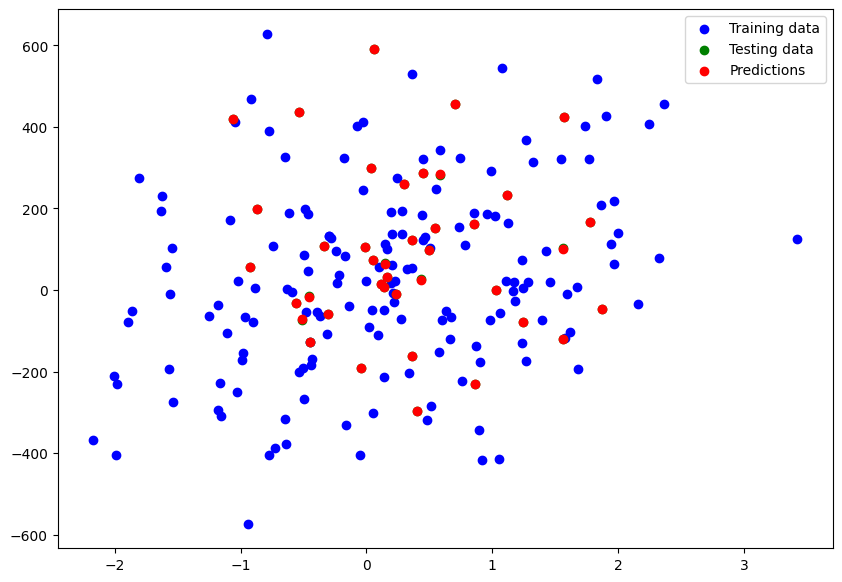

In [37]:
plot_predictions(X_train[: , 0] , y_train ,
                 X_test[: , 0] , y_test ,
                 y_preds_3)

Look at that! Our model has predicted every test data correctly. You can't spot a green dot (test data) it's because our predictions (red dot) overlapped.

Our model is doing a perfect job!

## Try and improve the results we got on the insurance dataset, some things you might want to try include:
- Building a larger model (how does one with 4 dense layers go?).
- Increasing the number of units in each layer.
- Lookup the documentation of Adam and find out what the first parameter is,what happens if you increase it by 10x?
- What happens if you train for longer (say 300 epochs instead of 200)?

### Building a larger model (how does one with 4 dense layers go?)

In [38]:
# Let's download the data
import pandas as pd
import numpy as np

data = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv')

data.shape

(1338, 7)

Our insurance data has 1338 rows and 7 columns

In [40]:
# Looking into the data
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We have some categorical variables, let's convert those columns into numerial used pandas.

In [41]:
# Turn categorical into numbers
data_one_hot = pd.get_dummies(data)
data_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [42]:
# Splitting into X and Y

X = data_one_hot.drop('charges' , axis = 1)
y = data_one_hot['charges']

X.shape , y.shape

((1338, 11), (1338,))

In [43]:
# Creating train and test split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

# Checking the shapes
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((1070, 11), (1070,), (268, 11), (268,))

In [44]:
# Building the model with 4 dense layers and more units

tf.random.set_seed(42)

# Create the model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(300) ,
  tf.keras.layers.Dense(200),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(50) ,
  tf.keras.layers.Dense(1)
])


# Compiling the model
model.compile(loss = tf.keras.losses.mae ,
              optimizer = tf.keras.optimizers.Adam() ,
              metrics = ['mae'])

# Fit the model
model.fit(X_train , y_train , epochs = 100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12146.2822 - mae: 12146.2822
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7410.9492 - mae: 7410.9492
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7099.2314 - mae: 7099.2314
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6739.4536 - mae: 6739.4536
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6582.9219 - mae: 6582.9219
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6500.6631 - mae: 6500.6631
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6398.9814 - mae: 6398.9814
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6329.1206 - mae: 6329.1206
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6200.1099 - mae: 6200.1099
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6064.3315 - mae: 6064.3315
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5832.3833 - mae: 5832.3833
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

### Lookup the documentation of Adam and find out what the first parameter is,what happens if you increase it by 10x?

And running for 400 epochs

In [45]:
# Let's tweak the Adam Optimizer's learning rate

tf.random.set_seed(42)

# Create the model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(100) ,
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])


# Compiling the model
model.compile(loss = tf.keras.losses.mae ,
              optimizer = tf.keras.optimizers.Adam(learning_rate= 0.001*10 ) ,
              metrics = ['mae'])

# Fit the model
history = model.fit(X_train , y_train , epochs = 400, verbose=1)

Epoch 1/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9910.8037 - mae: 9910.8037  
Epoch 2/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6870.8965 - mae: 6870.8965 
Epoch 3/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6249.9551 - mae: 6249.9551 
Epoch 4/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4806.2842 - mae: 4806.2842 
Epoch 5/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4275.9521 - mae: 4275.9521 
Epoch 6/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3830.1357 - mae: 3830.1357 
Epoch 7/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3785.9839 - mae: 3785.9839 
Epoch 8/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3749.7202 - mae: 3749.7202 
Epoch 9/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3830.3638 - mae: 3830.3638 
Epoch 10/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3683.0261 - mae: 3683.0261 
Epoch 11/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3925.9563 - mae: 3925.9563 
Epoch 12/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
# Evaluate on test data
model.evaluate(X_test , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3325.2773 - mae: 3325.2773  


[3274.302001953125, 3274.302001953125]

Text(0.5, 0, 'Epochs')

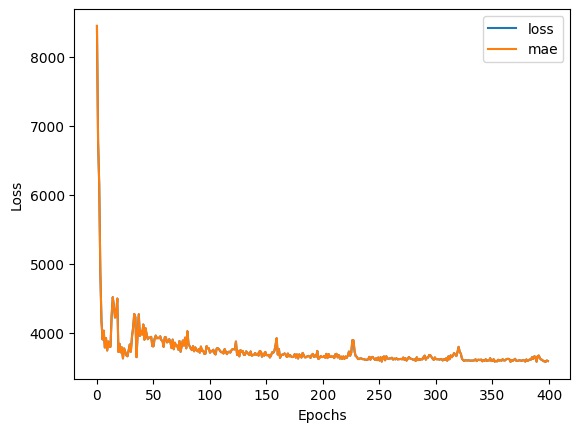

In [47]:
# Let's plot the loss curve Vs Epochs
pd.DataFrame(history.history).plot()
plt.ylabel('Loss')
plt.xlabel('Epochs')

Seems even increasing the learning rate and the number of epochs the model isn't performing an greater level.

## Import the Boston pricing dataset from TensorFlow `tf.keras.datasets` and model it.

In [48]:
# Getting the boston datasets from tensorflow datasets

(X_train , y_train) , (X_test , y_test) = tf.keras.datasets.boston_housing.load_data(path = 'boston_housing_npz' ,
                                                                           test_split = 0.2 , seed = 42)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [49]:
# Checkin the shape of our data
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((404, 13), (102, 13), (404,), (102,))

This datasets is numpy array format and it's normalized.

In [50]:
# Let's build a model

tf.random.set_seed(42)

# Building a model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(200),
  tf.keras.layers.Dense(200),
  tf.keras.layers.Dense(150),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])


# Compile the model
model.compile(loss = tf.keras.losses.mae ,
              optimizer = tf.keras.optimizers.Adam() ,
              metrics = ['mae'])

# Fit the model
history = model.fit(X_train , y_train , epochs  = 300 , verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 126.4816 - mae: 126.4816
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.3879 - mae: 21.3879 
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0934 - mae: 7.0934 
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2705 - mae: 9.2705 
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.9546 - mae: 9.9546   
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.0389 - mae: 8.0389 
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7161 - mae: 6.7161 
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3316 - mae: 7.3316 
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.3164 - mae: 8.3164 
Epoch 10/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.5510 - mae: 7.5510 
Epoch 11/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2567 - mae: 6.2567 
Epoch 12/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8073 - mae: 6.8073 
Epoch 13/300
13/13

In [51]:
# Let's evaluate on the test data
model.evaluate(X_test , y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.2655 - mae: 3.2655 


[3.2455267906188965, 3.2455267906188965]

Text(0.5, 0, 'epochs')

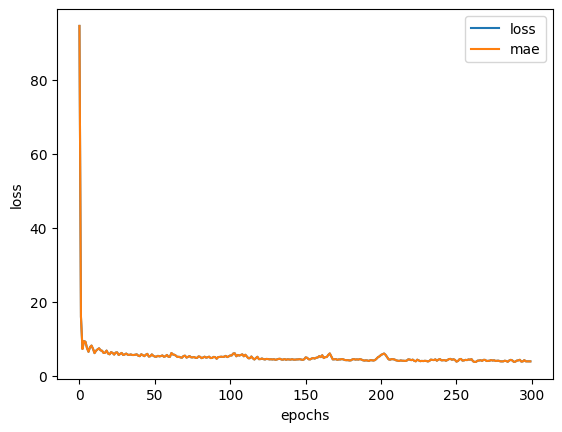

In [52]:
# Plotting the loss Vs Epoch
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')

Alright we're done solving Exercise of the modeule Neural Network Regression with TensorFlow.